<a href="https://colab.research.google.com/github/nitnelav27/workshopRedesUTDT/blob/main/Workshop_Redes_25_Septiembre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar "bibliotecas"

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Crear una redes pequeñas

Dos ejemplos: una red trivial de 5 nodos, y la red del club de karate del Dr. Zachary, con sus respectivas visualizaciones

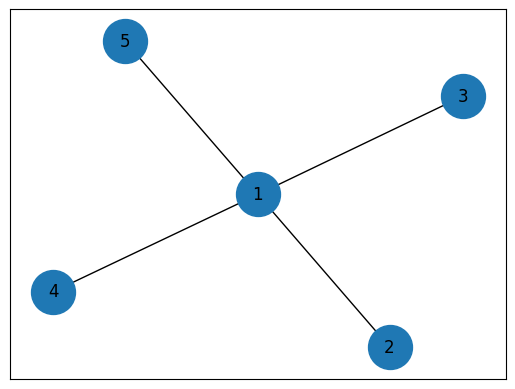

In [7]:
G = nx.Graph()
G.add_edge(1,2)
G.add_edge(1,3)
G.add_edge(1,4)
G.add_edge(1,5)
nx.draw_networkx(G, node_size=1000, with_labels=True)

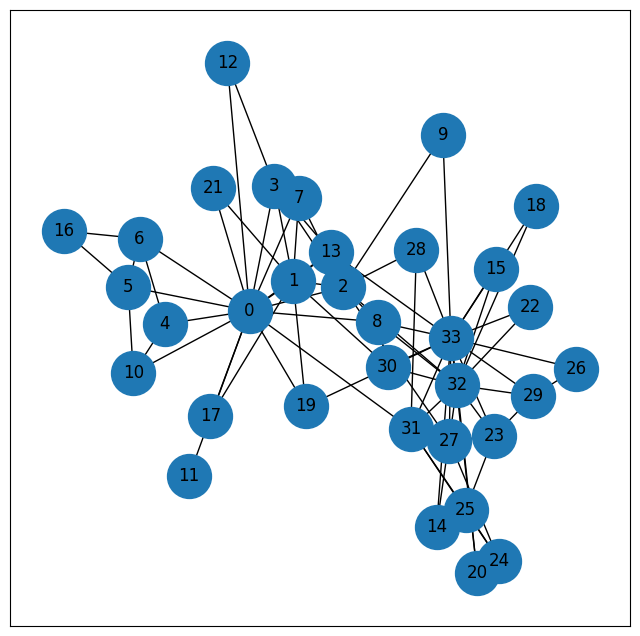

In [10]:
Z = nx.karate_club_graph()
plt.figure(figsize=(8,8))
nx.draw_networkx(Z, node_size=1000, with_labels=True)

# Redes de anillo

Un ejemplo y una función generadora

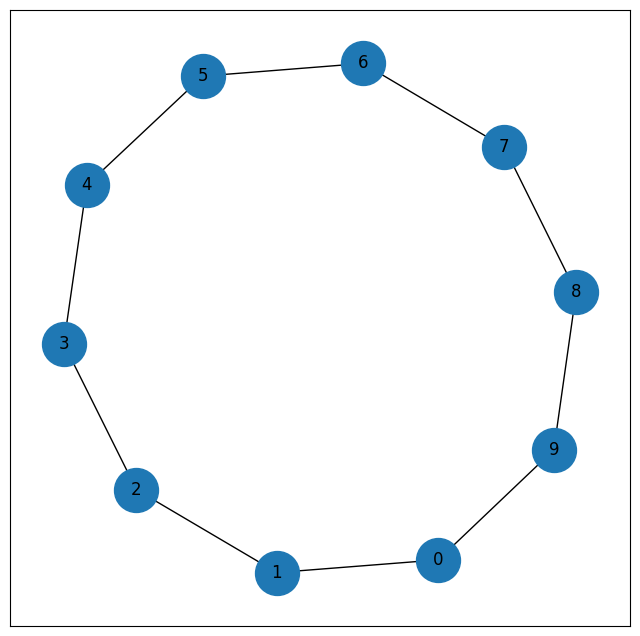

In [15]:
ejemploAnillo = nx.Graph()
for i in range(10):
    ejemploAnillo.add_edge(i, (i+1)%10)
plt.figure(figsize=(8,8))
nx.draw_networkx(ejemploAnillo, node_size=1000, with_labels=True)

In [18]:
## Función generadora
def anillo(n):
    G = nx.Graph()
    for i in range(n):
        G.add_edge(i, (i+1)%n)
    return G

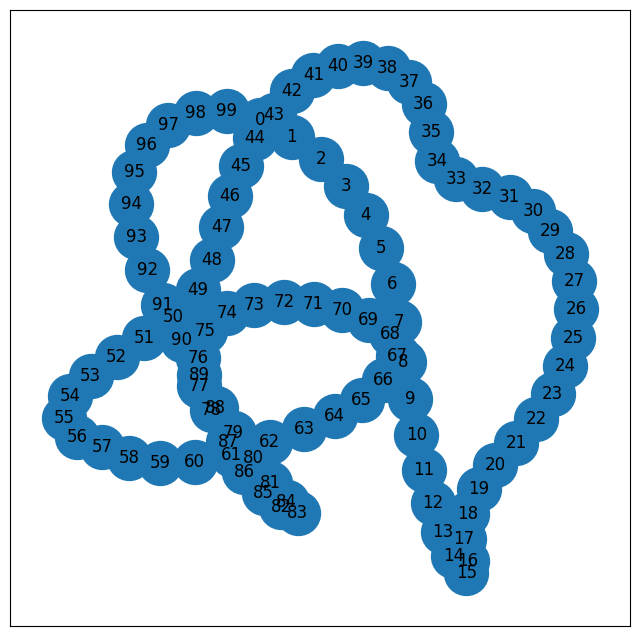

In [19]:
## Probando la función
G = anillo(100)
plt.figure(figsize=(8,8))
nx.draw_networkx(G, node_size=1000, with_labels=True)

<BarContainer object of 3 artists>

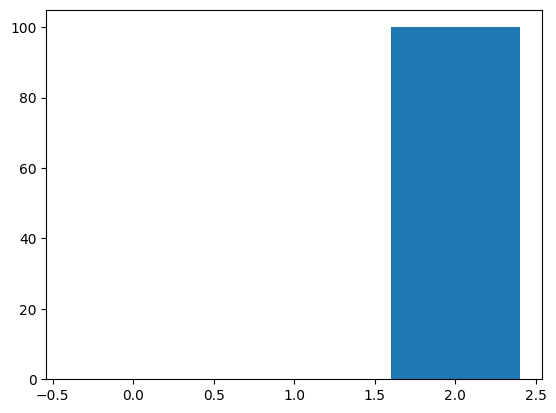

In [22]:
## Histograma de grado
Hk = nx.degree_histogram(G)
plt.bar(range(len(Hk)), Hk)

<BarContainer object of 3 artists>

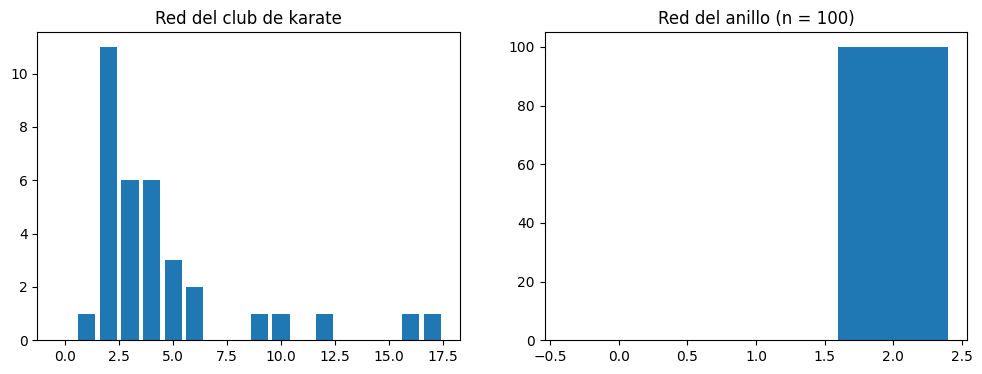

In [26]:
## Comparación con la red del club de karate
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.title("Red del club de karate")
HkZ = nx.degree_histogram(Z)
plt.bar(range(len(HkZ)), HkZ)
plt.subplot(122)
plt.title("Red del anillo (n = 100)")
HkR = nx.degree_histogram(anillo(100))
plt.bar(range(len(HkR)), HkR)

## Variante del anillo, aumentando vecinos


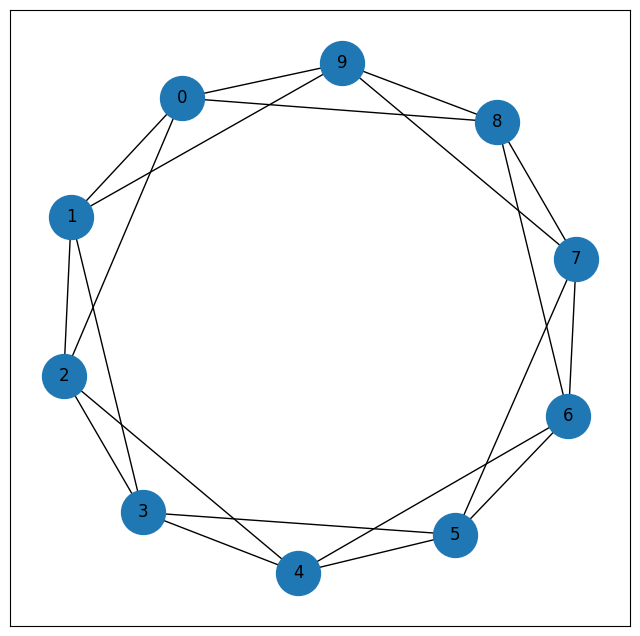

In [27]:
Rk4 = nx.Graph()
for i in range(10):
    Rk4.add_edge(i, (i+1)%10)
    Rk4.add_edge(i, (i+2)%10)

plt.figure(figsize=(8,8))
nx.draw_networkx(Rk4, node_size=1000, with_labels=True)

In [46]:
## Generalizando y modificando la función de anillo
def anillo(n, k=2):
    G = nx.Graph()
    r = k // 2
    for i in range(n):
        for j in range(1,r+1):
            G.add_edge(i, (i+j)%n)
    return G

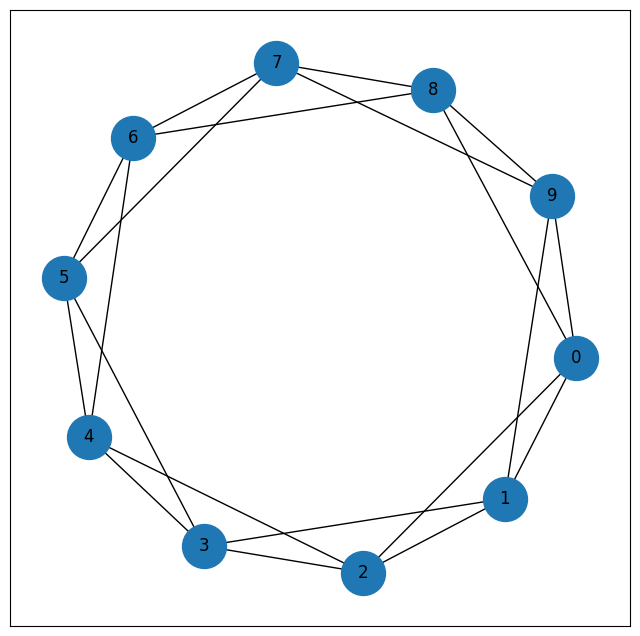

In [50]:
Rk4 = anillo(10, 4)
plt.figure(figsize=(8,8))
nx.draw_networkx(Rk4, node_size=1000, with_labels=True)

<BarContainer object of 5 artists>

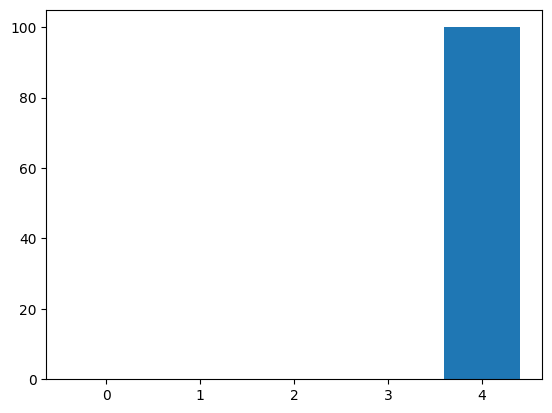

In [48]:
HkR = nx.degree_histogram(anillo(100, 4))
plt.bar(range(len(HkR)), HkR)

## Más medidas: transitividad y caminos cortos

In [55]:
nx.transitivity(anillo(100))

0

In [56]:
nx.average_shortest_path_length(anillo(100))

25.252525252525253

# Destruyendo y creando vínculos al azar

Con probabilidad $p$

In [57]:
p = 0.1
R = anillo(100)
Sw = R.copy()
for i,j in Sw.edges:
  if np.random.random() < p:
    Sw.remove_edge(i,j)
    h = np.random.choice(list(R.nodes))
    Sw.add_edge(i,h)

In [58]:
nx.transitivity(R), nx.transitivity(Sw)

(0, 0.02727272727272727)

In [59]:
nx.average_shortest_path_length(R), nx.average_shortest_path_length(Sw)

NetworkXError: Graph is not connected.

In [72]:
def caminosCortos(G):
  components = [G.subgraph(c) for c in nx.connected_components(G) if len(c) > 1]
  if components:
    total_length = sum(nx.average_shortest_path_length(comp) * len(comp) for comp in components)
    total_nodes = sum(len(comp) for comp in components)
    weighted_avg = total_length / total_nodes
    return weighted_avg
  return 0

In [74]:
caminosCortos(R), caminosCortos(Sw)

(25.252525252525253, 14.35538888888889)

In [77]:
## Solo para comparar con el club de karate
caminosCortos(Z), caminosCortos(anillo(Z.number_of_nodes()))

(2.408199643493761, 8.757575757575758)

# Simulemos Redes

Un anillo más grande como punto de partida, con $n = 1000$. Veamos el efecto de aumentar la probabilidad de destrucción/creación sobre la transitividad y caminos cortos

In [84]:
def generaSmallWorld(R, p):
  G = R.copy()
  for i,j in G.edges:
    if np.random.random() < p:
      G.remove_edge(i,j)
      h = np.random.choice(list(G.nodes))
      G.add_edge(i,h)
  return G

In [92]:
transitividadTodos = {}
caminosCortosTodos = {}
R = anillo(1000)
for p in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
  Sw = generaSmallWorld(R, p)
  transitividadTodos[p] = nx.transitivity(Sw)
  caminosCortosTodos[p] = caminosCortos(Sw)

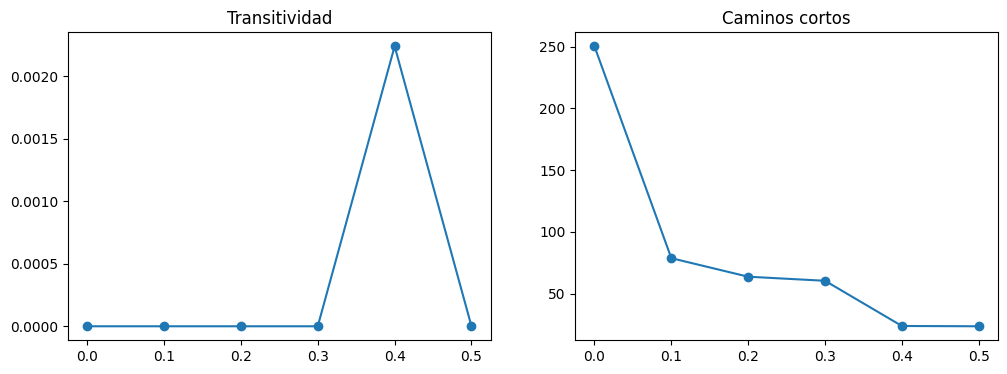

In [93]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.title("Transitividad")
plt.plot(list(transitividadTodos.keys()), list(transitividadTodos.values()), marker='o')
plt.subplot(122)
plt.title("Caminos cortos")
plt.plot(list(caminosCortosTodos.keys()), list(caminosCortosTodos.values()), marker='o')

In [95]:
transitividadTodos = {}
caminosCortosTodos = {}
for p in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
  Tlista = []
  CClista = []
  for _ in range(100):
    R = anillo(100)
    Sw = generaSmallWorld(R, p)
    Tlista.append(nx.transitivity(Sw))
    CClista.append(caminosCortos(Sw))
  transitividadTodos[p] = np.mean(Tlista)
  caminosCortosTodos[p] = np.mean(CClista)

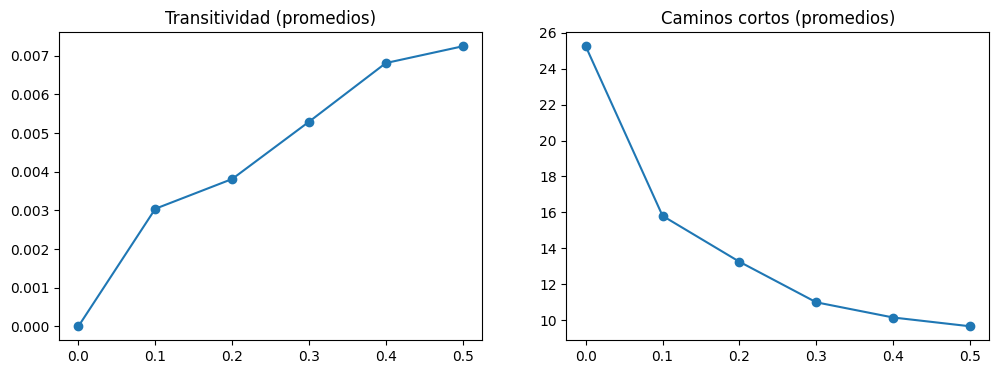

In [96]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.title("Transitividad (promedios)")
plt.plot(list(transitividadTodos.keys()), list(transitividadTodos.values()), marker='o')
plt.subplot(122)
plt.title("Caminos cortos (promedios)")
plt.plot(list(caminosCortosTodos.keys()), list(caminosCortosTodos.values()), marker='o')